In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

FEATURES_DIR = Path('../results/features')
FIG_DIR = Path('../results/figures')
MODEL_DIR = Path('../results/models')
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

df_train = pd.read_csv(FEATURES_DIR / 'features_train.csv')
df_test = pd.read_csv(FEATURES_DIR / 'features_test.csv')


def preparar(df):
    X = df.select_dtypes('number').replace([np.inf, -np.inf], np.nan).fillna(0)
    if 'forma_aspect_ratio' in X.columns:
        X['forma_aspect_ratio'] = X['forma_aspect_ratio'].clip(upper=5)
    return X, df['clase'].values

X_train, y_train = preparar(df_train)
X_test, y_test = preparar(df_test)
clases = sorted(np.unique(y_train))

# escalado: fit SOLO en train (sin leakage)
scaler = StandardScaler().fit(X_train)
Xtr = scaler.transform(X_train)
Xte = scaler.transform(X_test)

print(f'Train: {Xtr.shape}, Test: {Xte.shape}, {len(clases)} clases')

Train: (6750, 113), Test: (7096, 113), 9 clases


In [2]:
modelos = {
    'LogisticReg': LogisticRegression(max_iter=2000, random_state=0),
    'kNN (k=7)': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1),
    'HistGradBoost': HistGradientBoostingClassifier(random_state=0),
    'MLP': MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=0),
    'SVM-RBF': SVC(kernel='rbf', C=10, gamma=0.01, random_state=0),
}

comp = []
for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, Xtr, y_train, cv=5, n_jobs=-1, scoring='accuracy')
    comp.append({'Modelo': nombre, 'Accuracy CV': scores.mean(), 'Std': scores.std()})
    print(f'{nombre:<16} {scores.mean():.3f} +/- {scores.std():.3f}')

df_comp = pd.DataFrame(comp).sort_values('Accuracy CV', ascending=False).set_index('Modelo')
df_comp

LogisticReg      0.648 +/- 0.074
kNN (k=7)        0.648 +/- 0.080
RandomForest     0.698 +/- 0.097
HistGradBoost    0.751 +/- 0.089
MLP              0.721 +/- 0.073
SVM-RBF          0.733 +/- 0.075


,Accuracy CV,Std
Modelo,,
HistGradBoost,0.751407,0.089034
SVM-RBF,0.733185,0.074920
MLP,0.720593,0.073231
RandomForest,0.697630,0.096750
kNN (k=7),0.648296,0.079904
LogisticReg,0.648148,0.073670


In [3]:
# agrupar columnas por familia segun el prefijo
def familia(col):
    if col.startswith(('obj_lbp', 'full_lbp', 'obj_glcm', 'full_glcm')):
        return 'textura'
    if col.startswith(('obj_gabor', 'full_gabor')):
        return 'gabor'
    if col.startswith('forma_'):
        return 'forma'
    if col.startswith(('color_', 'lab_')):
        return 'color'
    if col.startswith('int_'):
        return 'intensidad'
    return 'otro'

grupos = {}
for col in X_train.columns:
    grupos.setdefault(familia(col), []).append(col)

print('Features por familia:')
for g, cols in grupos.items():
    print(f'  {g}: {len(cols)}')

# combos a evaluar
combos = {
    'Solo textura': ['textura'],
    'Solo color': ['color'],
    'Solo forma': ['forma'],
    'Textura + color': ['textura', 'color'],
    'Textura + color + forma': ['textura', 'color', 'forma'],
    'Todo sin Gabor': ['textura', 'color', 'forma', 'intensidad'],
    'Todo con Gabor': ['textura', 'color', 'forma', 'intensidad', 'gabor'],
}

svm_abl = SVC(kernel='rbf', C=10, gamma=0.01, random_state=0)
abl = []
for nombre, fams in combos.items():
    cols = [c for f in fams for c in grupos.get(f, [])]
    if not cols:
        continue
    Xsub = StandardScaler().fit_transform(X_train[cols])
    scores = cross_val_score(svm_abl, Xsub, y_train, cv=5, n_jobs=-1)
    abl.append({'Configuracion': nombre, 'N features': len(cols), 'Accuracy CV': scores.mean()})
    print(f'{nombre:<26} ({len(cols):>3} feat): {scores.mean():.3f}')

df_abl = pd.DataFrame(abl).set_index('Configuracion')
df_abl

Features por familia:
  textura: 28
  gabor: 48
  intensidad: 5
  forma: 13
  color: 19
Solo textura               ( 28 feat): 0.567
Solo color                 ( 19 feat): 0.541
Solo forma                 ( 13 feat): 0.318
Textura + color            ( 47 feat): 0.698
Textura + color + forma    ( 60 feat): 0.710
Todo sin Gabor             ( 65 feat): 0.719
Todo con Gabor             (113 feat): 0.733


,N features,Accuracy CV
Configuracion,,
Solo textura,28,0.567259
Solo color,19,0.540593
Solo forma,13,0.317778
Textura + color,47,0.698222
Textura + color + forma,60,0.709630
Todo sin Gabor,65,0.718815
Todo con Gabor,113,0.733185


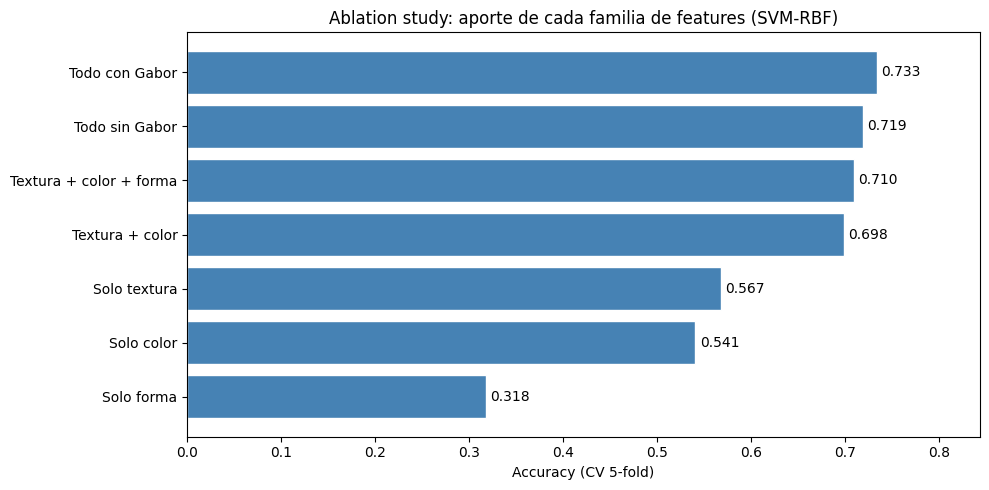

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))
orden = df_abl.sort_values('Accuracy CV')
barras = ax.barh(orden.index, orden['Accuracy CV'], color='steelblue', edgecolor='white')
ax.bar_label(barras, fmt='%.3f', padding=3, fontsize=10)
ax.set_xlabel('Accuracy (CV 5-fold)')
ax.set_title('Ablation study: aporte de cada familia de features (SVM-RBF)')
ax.set_xlim(0, max(orden['Accuracy CV']) * 1.15)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_ablation_features.png', dpi=200, bbox_inches='tight')
plt.show()

In [5]:
grid = GridSearchCV(
    SVC(kernel='rbf', random_state=0),
    {'C': [1, 10, 50, 100], 'gamma': ['scale', 0.005, 0.01, 0.05]},
    cv=5, n_jobs=-1, scoring='accuracy', verbose=1
)
grid.fit(Xtr, y_train)
print('Mejores parametros:', grid.best_params_)
print('Mejor accuracy CV:', grid.best_score_)

mejor_svm = grid.best_estimator_

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Mejores parametros: {'C': 50, 'gamma': 0.005}
Mejor accuracy CV: 0.733925925925926


=== EVALUACION FINAL EN TEST ===
              precision    recall  f1-score   support

     battery      0.661     0.721     0.690       750
   cardboard      0.680     0.729     0.704       750
       glass      0.695     0.549     0.614       750
       metal      0.599     0.604     0.602       750
     organic      0.778     0.840     0.808       750
       paper      0.774     0.621     0.689       750
     plastic      0.558     0.568     0.563       750
     textile      0.785     0.777     0.781      1096
       trash      0.694     0.797     0.742       750

    accuracy                          0.694      7096
   macro avg      0.691     0.690     0.688      7096
weighted avg      0.696     0.694     0.692      7096



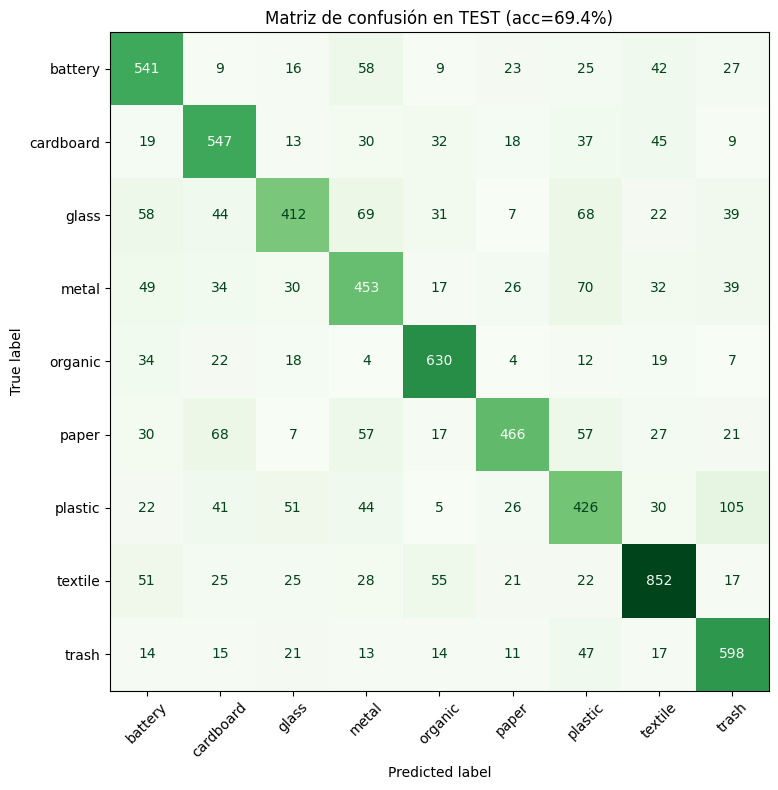

In [6]:
y_test_pred = mejor_svm.predict(Xte)

print('=== EVALUACION FINAL EN TEST ===')
print(classification_report(y_test, y_test_pred, digits=3))

fig, ax = plt.subplots(figsize=(9, 8))
cm = confusion_matrix(y_test, y_test_pred, labels=clases)
ConfusionMatrixDisplay(cm, display_labels=clases).plot(ax=ax, cmap='Greens', xticks_rotation=45, colorbar=False)
ax.set_title(f'Matriz de confusión en TEST (acc={accuracy_score(y_test, y_test_pred):.1%})')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_matriz_confusion_test.png', dpi=200, bbox_inches='tight')
plt.show()

In [7]:
# reentrenar con probabilidades activadas (lo necesita el hibrido)
svm_final = SVC(kernel='rbf', probability=True, random_state=0, **grid.best_params_)
svm_final.fit(Xtr, y_train)

joblib.dump(svm_final, MODEL_DIR / 'svm_clasico.pkl')
joblib.dump(scaler, MODEL_DIR / 'scaler_clasico.pkl')
joblib.dump(list(X_train.columns), MODEL_DIR / 'features_clasico.pkl')
print('Guardado: modelo, scaler y lista de features')

Guardado: modelo, scaler y lista de features
